In [1]:
import lhapdf
import pyhepmc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as mh
import seaborn as sns
mh.style.use("CMS")

In [2]:
# initialization of some variables
input_file = "../event_files/nuDIS_charged/tag_1_pythia8_events.hepmc.gz"
n_events = None
n_mux = 9

pdf_name = "NNPDF23_lo_as_0130_qed"
pdf_set = lhapdf.getPDFSet(pdf_name)
pdf_size = pdf_set.size-1

In [3]:
def get_events(input_file_path):
    """ returns a list of events using pyhepmc """

    with pyhepmc.open(input_file_path, format="hepmc2") as file:
        events = list(file)
    return events

In [4]:
def read_events(kevents):
    """ 
    read events and returns two dataframes:
    events_record_df: with relevant parameters (weights, pt, etc) for all particles in the final state of each event
    events_info_df: with information about the event, such as weights and 9-point scale variations
    """
    
    events_record = []
    events_info = []
    for ievt, event in enumerate(kevents):
        weight = event.weights[0]
        for p in event.particles:
            # keep only final state particles
            if p.status != 1:
                continue
            pid = p.pid
            pN = p.momentum

            # saves information in dictionary format
            events_record.append({
                "event": ievt,
                "ID": pid,
                "weight": weight,
                "p_{T}": pN.pt(),
                "y": pN.rap()
                })
            
        # record weights and 9-point scale uncertainties for each event, using dynamical scale choice 3
        # the variation on mux follows: w_mur_muf, (e.g. "w_05_10" means mur=0.5, muf=1.0)
        # the values are hardcoded, so be mindful when dealing with other hepmc files or mg5 versions
        # in this case, the weights follow: 0 = central, 1 = nominal weight, {mux variation}, {pdf variations}, resulting in 146 elements
        events_info.append({
            "event": ievt,
            "wgt_central": weight,
            "w_05_05": event.weights[3],
            "w_05_10": event.weights[4],
            "w_05_20": event.weights[5],
            "w_10_05": event.weights[6],
            "w_10_10": event.weights[7], 
            "w_10_20": event.weights[8],
            "w_20_05": event.weights[9],
            "w_20_10": event.weights[10],
            "w_20_20": event.weights[11]
            })
        
    events_record_df = pd.DataFrame(events_record)
    events_info_df = pd.DataFrame(events_info)
    
    return events_record_df, events_info_df
    

In [5]:
# auxiliary functions for plotting
def build_scale_hist(df,  observable, bins=30):

    if observable == "p_{T}":
        xrange = (0,30)
    elif observable == "y":
        xrange = (-5,15)
    else:
        xrange = (0,50)
        
    n_evts = df["event"].max() + 1
    var_columns = [i for i in df.columns if i.startswith("w_")]

#     hist_nom, bin_edges = np.histogram(df[observable], bins=bins, weights=df["weight"]/n_evts)

    hist_mux_array = [None]*len(var_columns)

    for j, mux_name in enumerate(var_columns):
            hist_mux_array[j], _ = np.histogram(df[observable], weights=df[mux_name]/n_evts, bins=bins, range=xrange)

    # build max, min, central from 9-point envelope
    hist_mux_hix = np.maximum.reduce(hist_mux_array)
    hist_mux_lox = np.minimum.reduce(hist_mux_array)

    return hist_mux_lox, hist_mux_hix

In [6]:
def plot_particle_dist(particle_dict, observable, bins=30, show_uncertainty=True):

    fig, ax = plt.subplots(figsize=(8,6))
    if observable == "p_{T}":
        xrange = (0,30)
    elif observable == "y":
        xrange = (-5,15)
    else:
        xrange = (0,50)

    colors = {label : sns.color_palette('deep', n_colors=20)[i] for i,label in enumerate(particle_dict.keys())}    

    for label, df in particle_dict.items():

        hist_mu_lox, hist_mu_hix = build_scale_hist(df, observable,bins)

        # bin_center = 0.5*(bin_edges[1:] + bin_edges[:-1])
        n_evts = df["event"].max() + 1
        
        hist_mux_cen, tmp_bins, tmp_bars = ax.hist(df[observable], bins=bins, weights=df["wgt_central"]/n_evts, 
                                                   histtype='step', color=colors[label], linewidth=2.0, label=label, range=xrange) 

        if show_uncertainty:

            ax.bar(x=tmp_bins[:-1], height=hist_mu_hix-hist_mu_lox, bottom=hist_mu_lox, width=np.diff(tmp_bins), 
                   align='edge', zorder=-1, color=colors[label], alpha=0.6)

    # ax.set_yscale("log")
    ax.set_xlabel(r"$%s$" %(observable), loc="center")
    # ax.set_ylabel(r'$d\sigma/dp_T$',loc="center")
    ax.set_ylabel(r'$N$ (normalized)',loc="center")

    ax.legend()

    return fig, ax

In [7]:
events = get_events(input_file)
events_record_df, events_info_df = read_events(events)
print("Total cross-section: %.3f pb." %(events_info_df["wgt_central"].sum()/len(events_info_df["wgt_central"])))

Total cross-section: 6.095 pb.


In [8]:
n_evts = events_record_df["event"].max()+1
print("Total number of generated events: %i" %(n_evts))

Total number of generated events: 9997


In [9]:
events_record_df["ID"].unique()

array([  211,   321,  -211,    11,    22,  2212,   130,  -321,  2112,
       -2112,   -11,    12, -2212,   -13,    14,    13,   -14,    16,
         -16,   -12])

In [10]:
def get_particle_df(pid):
    return (events_record_df[events_record_df["ID"] == pid].merge(events_info_df, on="event"))

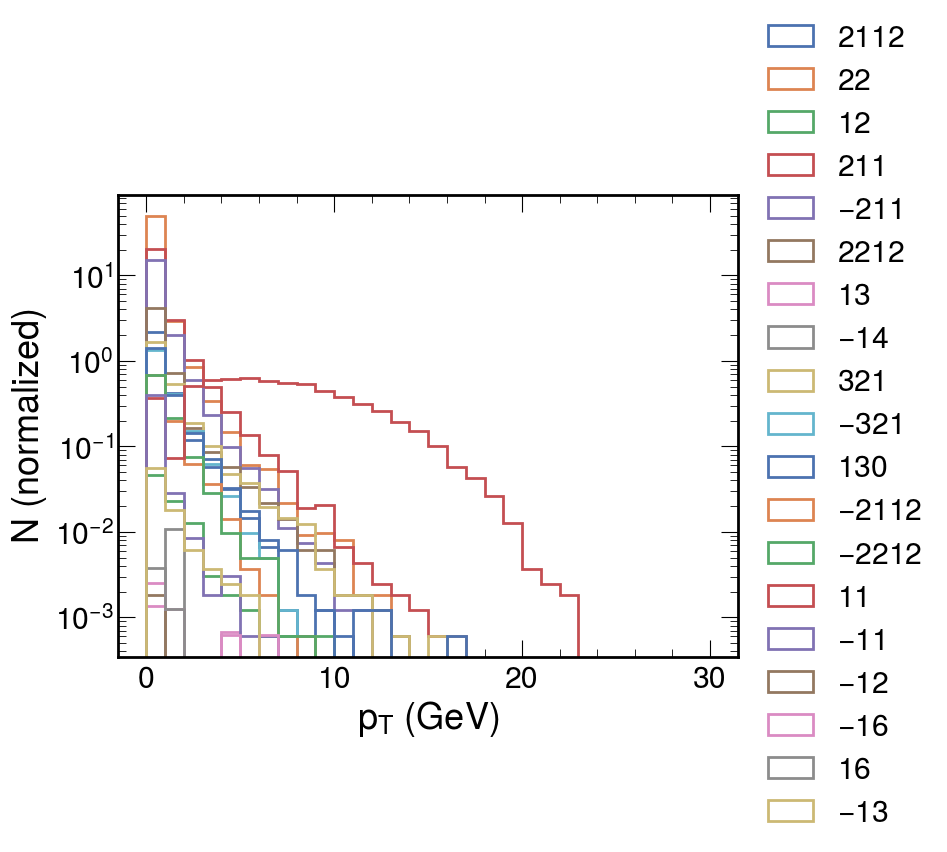

In [11]:
fig, ax = plot_particle_dist(particle_dict={r"$2112$": get_particle_df(2112),
                                            r"$22$": get_particle_df(22),
                                            r"$12$": get_particle_df(12),
                                            r"$211$": get_particle_df(211),
                                            r"$-211$": get_particle_df(-211),
                                            r"$2212$": get_particle_df(2212),
                                            r"$2112$": get_particle_df(2112),
                                            r"$13$": get_particle_df(13),
                                            r"$-14$": get_particle_df(-14),
                                            r"$321$": get_particle_df(321),
                                            r"$-321$": get_particle_df(-321),
                                            r"$130$": get_particle_df(130),
                                            r"$-2112$": get_particle_df(-2112),
                                            r"$-2212$": get_particle_df(-2212),
                                            r"$11$": get_particle_df(11),
                                            r"$-11$": get_particle_df(-11),
                                            r"$-12$": get_particle_df(-12),
                                            r"$-16$": get_particle_df(-16),
                                            r"$16$": get_particle_df(16),
                                            r"$-13$": get_particle_df(-13)},
                             observable="p_{T}", show_uncertainty=False)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel(r"$p_{T}$ (GeV)", loc="center")
plt.yscale("log")
plt.show()

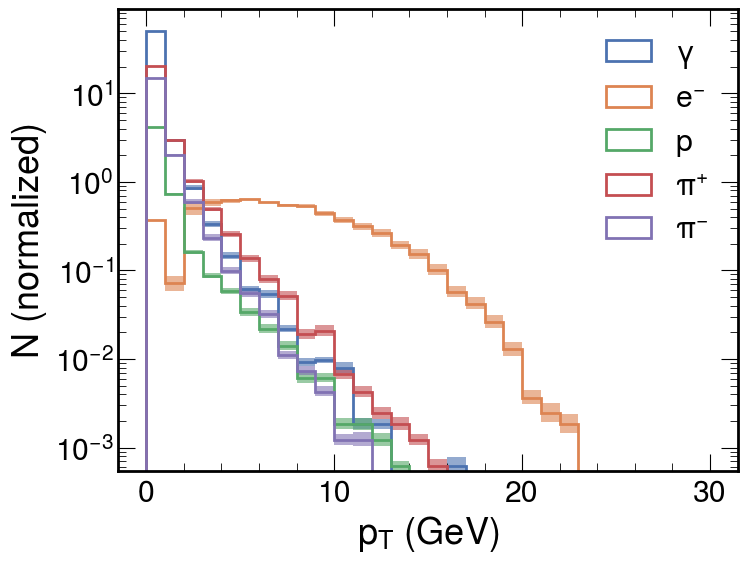

In [12]:
fig, ax = plot_particle_dist(particle_dict={r"$\gamma$": get_particle_df(22),
                                            r"$e^{-}$": get_particle_df(11),
                                            r"$p$": get_particle_df(2212),
                                            r"$\pi^{+}$": get_particle_df(211),
                                            r"$\pi^{-}$": get_particle_df(-211)},
                             observable="p_{T}")
plt.xlabel(r"$p_{T}$ (GeV)", loc="center")
plt.yscale("log")
plt.show()

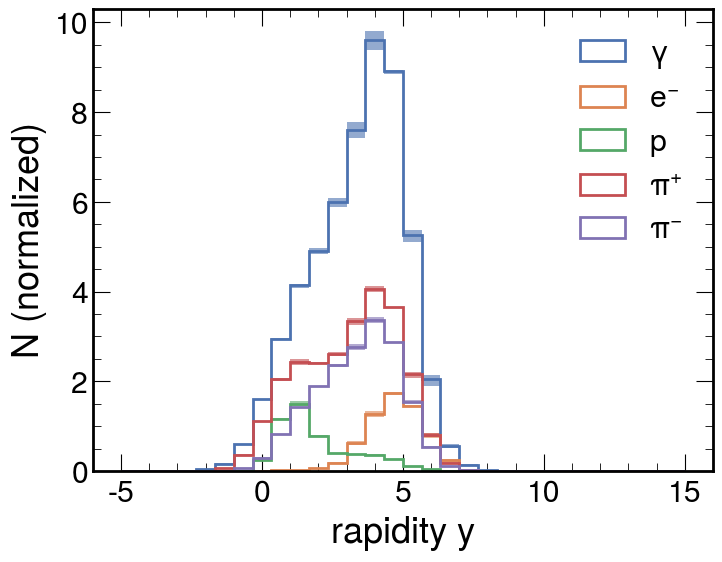

In [13]:
fig, ax = plot_particle_dist(particle_dict={r"$\gamma$": get_particle_df(22),
                                            r"$e^{-}$": get_particle_df(11),
                                            r"$p$": get_particle_df(2212),
                                            r"$\pi^{+}$": get_particle_df(211),
                                            r"$\pi^{-}$": get_particle_df(-211)},
                             observable="y")
plt.xlabel(r"rapidity $y$", loc="center")
plt.show()

In [14]:
# multiplicity
def particle_multiplicity(pid, n_evts):

    counts = (events_record_df[events_record_df["ID"] == pid].groupby("event").size()) # count number of particles with PID=ID in each event
    mult = pd.DataFrame({"event": np.arange(n_evts)})
    mult["multiplicity"] = (mult["event"].map(counts).fillna(0).astype(int)) # create multiplicity column
    return mult.merge(events_info_df, on="event") 

In [15]:
# average multiplicity
multi = {r"$\gamma$": particle_multiplicity(22, n_evts=n_evts), r"$e^{-}$": particle_multiplicity(11, n_evts=n_evts),
         r"$\pi^{+}$": particle_multiplicity(211, n_evts=n_evts), r"$\pi^{-}$": particle_multiplicity(-211, n_evts=n_evts),
         r"$p$": particle_multiplicity(2212, n_evts=n_evts), r"$n$": particle_multiplicity(2112, n_evts=n_evts)}



avg_multi = {p: 0 for p in multi.keys()}

for p in multi.keys():
    xsec = multi[p]["wgt_central"].sum()
    avg_multi[p] = (multi[p]["multiplicity"] * multi[p]["wgt_central"]).sum() / xsec


avg_multi_df = pd.DataFrame({"particle": avg_multi.keys(), "average miltiplicity": avg_multi.values()})
avg_multi_df = avg_multi_df.sort_values(by="average miltiplicity", ascending=False)


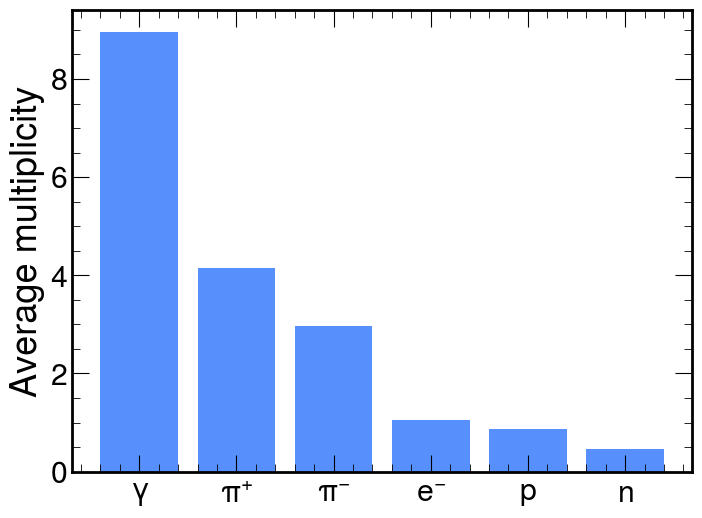

In [16]:
fig, ax = plt.subplots(figsize=(8,6))

plt.bar(avg_multi_df["particle"], avg_multi_df["average miltiplicity"])

plt.ylabel("Average multiplicity", loc="center")
plt.show()

In [17]:
avg_multi_df

,particle,average miltiplicity
0,$\gamma$,8.963472
2,$\pi^{+}$,4.147516
3,$\pi^{-}$,2.973507
1,$e^{-}$,1.058505
4,$p$,0.868440
5,$n$,0.466031


In [20]:
events_record_df

,event,ID,weight,p_{T},y
0,0,211,6.1142,0.263115,4.113304
1,0,321,6.1142,0.226280,3.945779
2,0,-211,6.1142,0.605212,3.180891
3,0,-211,6.1142,0.505173,0.913485
4,0,11,6.1142,6.858500,3.715287
...,...,...,...,...,...
200068,9996,22,6.1142,0.134672,3.468545
200069,9996,22,6.1142,0.128301,3.238924
200070,9996,22,6.1142,0.060082,2.618827
200071,9996,22,6.1142,0.068226,1.276998


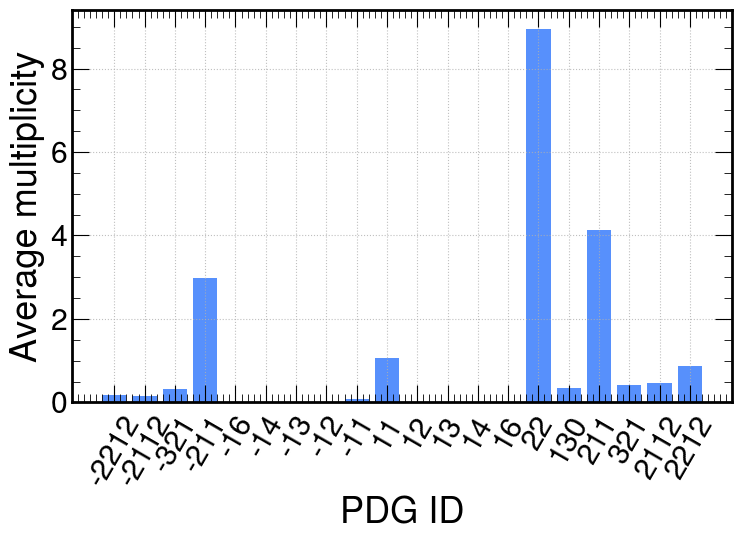

In [46]:
# same thing, but for all PDGs in the events
avg_multi_all = (events_record_df.groupby("ID").size().reset_index(name="average multiplicity"))

avg_multi_all["average multiplicity"] /= n_evts

fig, ax = plt.subplots(figsize=(8,6))

plt.bar(avg_multi_all["ID"].astype(str), avg_multi_all["average multiplicity"])

plt.ylabel("Average multiplicity", loc="center")
plt.xlabel("PDG ID", loc="center")
plt.xticks(rotation=60)
plt.grid()

plt.tight_layout()
plt.show()


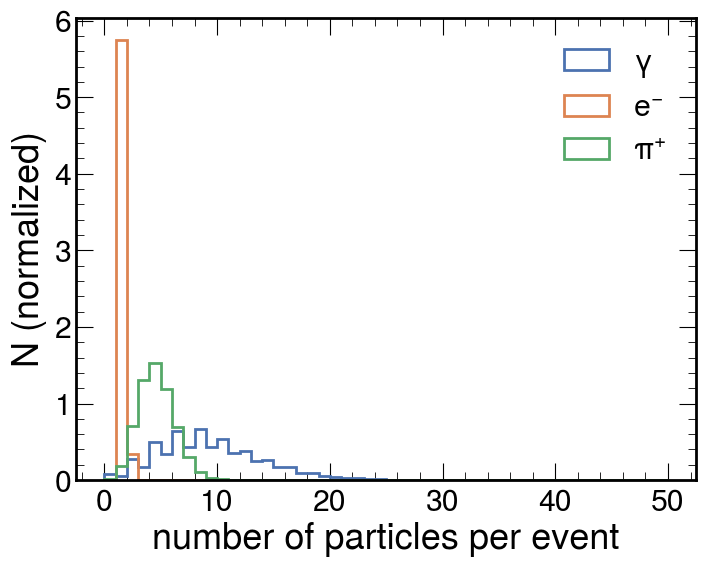

In [18]:
fig, ax = plot_particle_dist(particle_dict={r"$\gamma$": particle_multiplicity(22, n_evts=n_evts),
                                            r"$e^{-}$": particle_multiplicity(11, n_evts=n_evts),
                                            r"$\pi^{+}$": particle_multiplicity(211, n_evts=n_evts),},
                             observable="multiplicity", show_uncertainty=False, bins=50)
plt.xlabel(r"number of particles per event", loc="center")
plt.show()

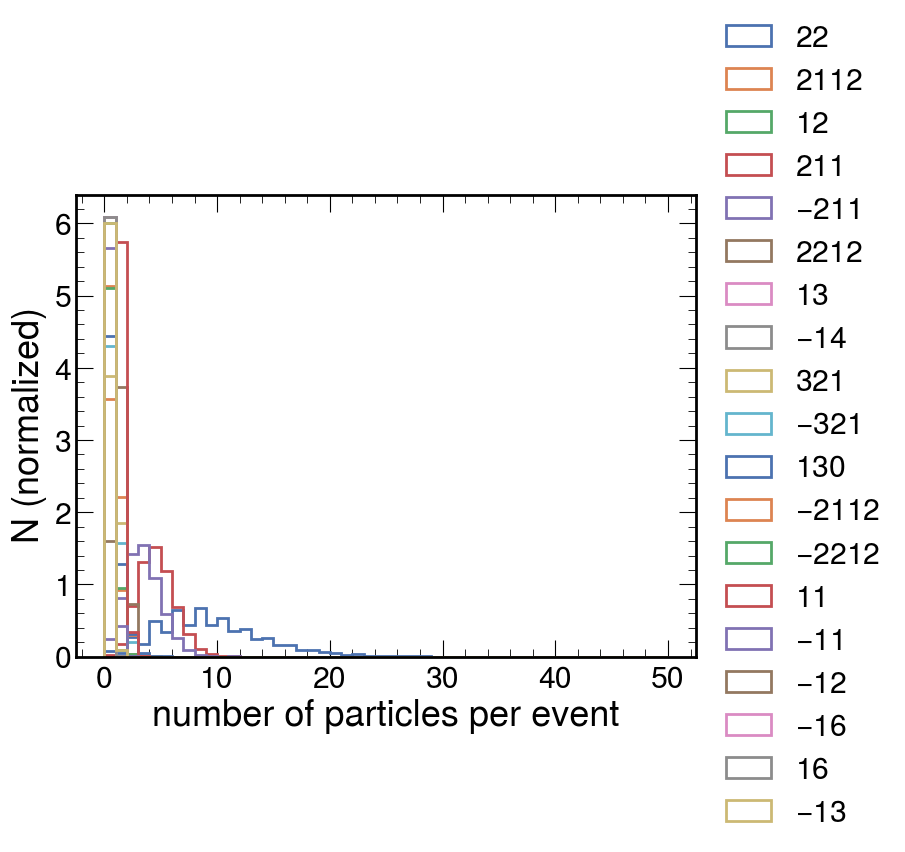

In [19]:
fig, ax = plot_particle_dist(particle_dict={r"$22$": particle_multiplicity(22, n_evts=n_evts),
                                            r"$2112$": particle_multiplicity(2112, n_evts=n_evts),
                                            r"$22$": particle_multiplicity(22, n_evts=n_evts),
                                            r"$12$": particle_multiplicity(12, n_evts=n_evts),
                                            r"$211$": particle_multiplicity(211, n_evts=n_evts),
                                            r"$-211$": particle_multiplicity(-211, n_evts=n_evts),
                                            r"$2212$": particle_multiplicity(2212, n_evts=n_evts),
                                            r"$2112$": particle_multiplicity(2112, n_evts=n_evts),
                                            r"$13$": particle_multiplicity(13, n_evts=n_evts),
                                            r"$-14$": particle_multiplicity(-14, n_evts=n_evts),
                                            r"$321$": particle_multiplicity(321, n_evts=n_evts),
                                            r"$-321$": particle_multiplicity(-321, n_evts=n_evts),
                                            r"$130$": particle_multiplicity(130, n_evts=n_evts),
                                            r"$-2112$": particle_multiplicity(-2112, n_evts=n_evts),
                                            r"$-2212$": particle_multiplicity(-2212, n_evts=n_evts),
                                            r"$11$": particle_multiplicity(11, n_evts=n_evts),
                                            r"$-11$": particle_multiplicity(-11, n_evts=n_evts),
                                            r"$-12$": particle_multiplicity(-12, n_evts=n_evts),
                                            r"$-16$": particle_multiplicity(-16, n_evts=n_evts),
                                            r"$16$": particle_multiplicity(16, n_evts=n_evts),
                                            r"$-13$": particle_multiplicity(-13, n_evts=n_evts)},
                             observable="multiplicity", show_uncertainty=False, bins=50)
plt.xlabel(r"number of particles per event", loc="center")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()